In [1]:
# IMPORTAR LIBRERIAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# CARGAR DATASET
df = pd.read_csv("data.txt")

# quita espacios y tabs
df.columns = df.columns.str.replace('\t', '', regex=True)
df.columns = df.columns.str.strip()

df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
# ANALISIS EXPLORATORIO (EDA)
# info
df.info()

#Estadistica
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [4]:
# conteo de clases
df['Target'].value_counts()

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

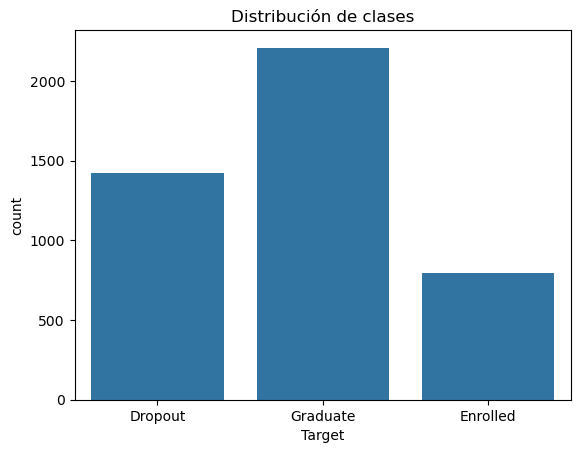

In [5]:
# VISUALIZACION

# distribucion de la variable de objetivo
sns.countplot(x='Target', data=df)
plt.title("Distribución de clases")
plt.show()

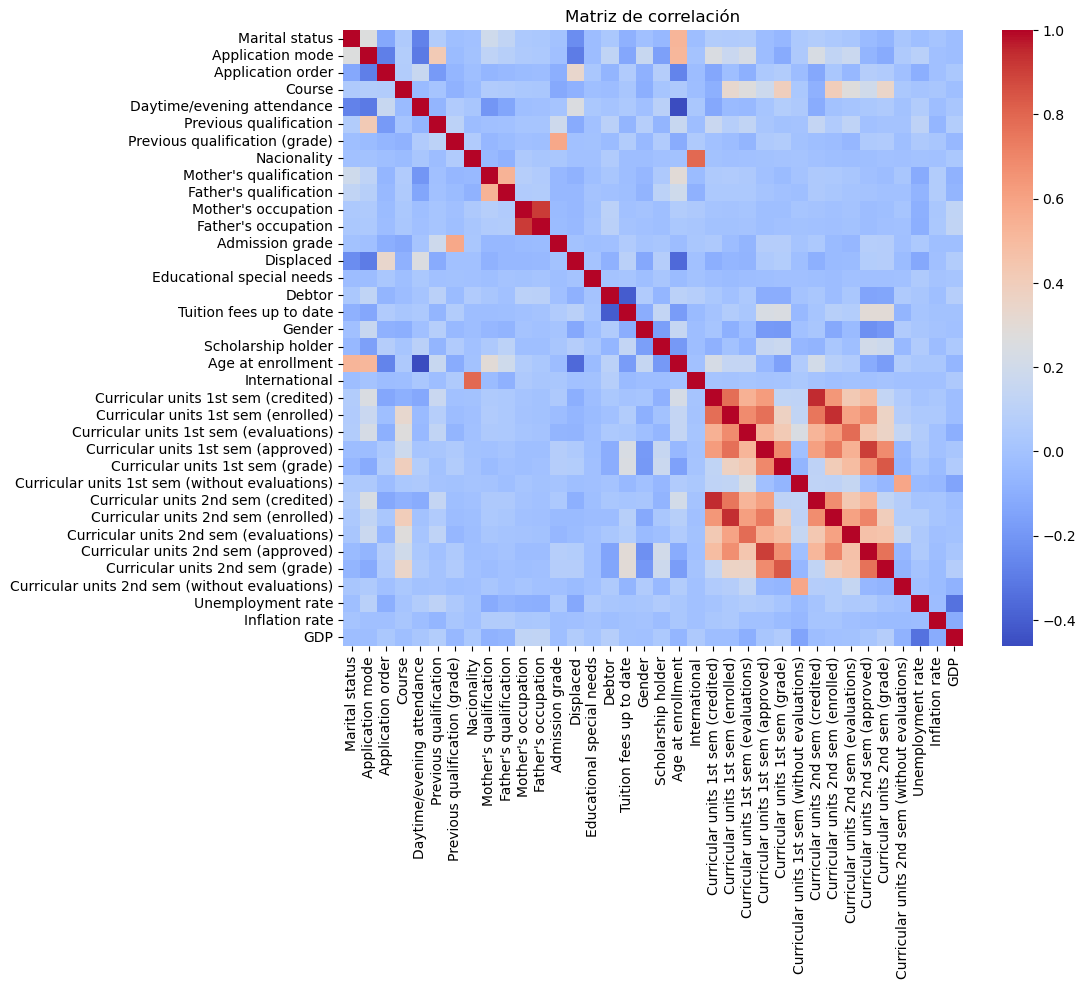

In [6]:
# matriz de correlacion ()
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include='number').corr(), cmap='coolwarm')
plt.title("Matriz de correlación")
plt.show()

In [7]:
# PROCESAMIENTO
from sklearn.preprocessing import LabelEncoder

# Convertir Target a números
le = LabelEncoder()
df['Target'] = le.fit_transform(df['Target'])

In [8]:
# Separar variables
X = df.drop('Target', axis=1)
y = df['Target']

In [9]:
# NORMALIZACIÓN

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
# DIVISIÓN DE DATOS

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [11]:
# MODELO KNN

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

In [12]:
# MODELO NAIVE BAYES

from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

In [13]:
# EVALUACIÓN

from sklearn.metrics import roc_auc_score

roc_knn = roc_auc_score(y_test, knn.predict_proba(X_test), multi_class='ovr')
roc_nb = roc_auc_score(y_test, nb.predict_proba(X_test), multi_class='ovr')

print("ROC KNN:", roc_knn)
print("ROC NB:", roc_nb)

ROC KNN: 0.7911920804438349
ROC NB: 0.801522468495739


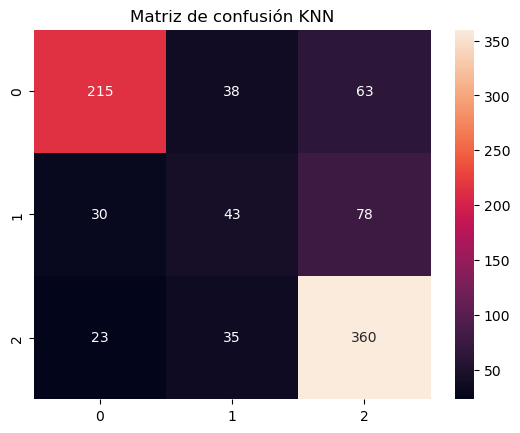

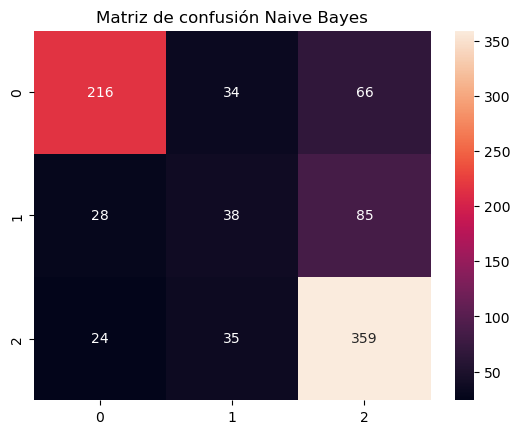

In [14]:
# MATRIZ DE CONFUSIÓN

from sklearn.metrics import confusion_matrix

cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure()
sns.heatmap(cm_knn, annot=True, fmt='d')
plt.title("Matriz de confusión KNN")
plt.show()

plt.figure()
sns.heatmap(cm_nb, annot=True, fmt='d')
plt.title("Matriz de confusión Naive Bayes")
plt.show()


In [15]:
# REPORTE DE CLASIFICACIÓN
from sklearn.metrics import classification_report

print("KNN:\n", classification_report(y_test, y_pred_knn))
print("Naive Bayes:\n", classification_report(y_test, y_pred_nb))

KNN:
               precision    recall  f1-score   support

           0       0.80      0.68      0.74       316
           1       0.37      0.28      0.32       151
           2       0.72      0.86      0.78       418

    accuracy                           0.70       885
   macro avg       0.63      0.61      0.61       885
weighted avg       0.69      0.70      0.69       885

Naive Bayes:
               precision    recall  f1-score   support

           0       0.81      0.68      0.74       316
           1       0.36      0.25      0.29       151
           2       0.70      0.86      0.77       418

    accuracy                           0.69       885
   macro avg       0.62      0.60      0.60       885
weighted avg       0.68      0.69      0.68       885



In [16]:
# probar distintos k
for k in range(1,10):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    print(k, knn.score(X_test, y_test))

1 0.6519774011299435
2 0.632768361581921
3 0.6813559322033899
4 0.6858757062146893
5 0.6983050847457627
6 0.696045197740113
7 0.7028248587570621
8 0.711864406779661
9 0.7141242937853107


In [17]:
# VALIDACION CRUZADA CON KNN (k=5)
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(KNeighborsClassifier(n_neighbors=5), X_scaled, y, cv=5)

print(cv_scores)
print("CV_SCORES MEAN: {}".format(np.mean(cv_scores)))


[0.70282486 0.70621469 0.70847458 0.70621469 0.68438914]
CV_SCORES MEAN: 0.7016235907661631


In [18]:
# BUSCAR EL MEJOR K PROBANDO VARIOS VALORES CON VALIDACION CRUZADA
k_range = range(1, 31)
k_scores = []

for k in k_range:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_k, X_scaled, y, cv=5, scoring='accuracy')
    k_scores.append(scores.mean())


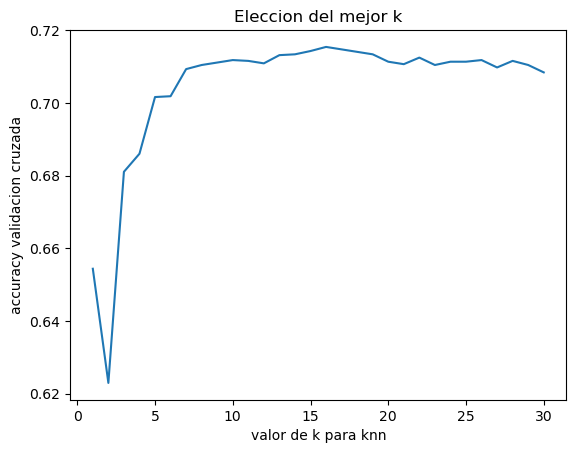

In [19]:
# GRAFICO DE K VS ACCURACY
plt.plot(k_range, k_scores)
plt.xlabel('valor de k para knn')
plt.ylabel('accuracy validacion cruzada')
plt.title('Eleccion del mejor k')
plt.show()


In [20]:
# TABLA DE K Y SU ACCURACY
tune = pd.concat([pd.DataFrame(k_range), pd.DataFrame(k_scores)], axis=1)
tune.columns = ['k_range', 'k_scores']
tune


,k_range,k_scores
0,1,0.654381
1,2,0.622966
2,3,0.681056
3,4,0.686025
4,5,0.701624
5,6,0.701850
6,7,0.709309
7,8,0.710439
8,9,0.711115
9,10,0.711795


In [21]:
# MODELO KNN FINAL CON EL MEJOR K ENCONTRADO
mejor_k = k_range[np.argmax(k_scores)]
print("Mejor k:", mejor_k)

knn_final = KNeighborsClassifier(n_neighbors=mejor_k)
knn_final.fit(X_train, y_train)
y_pred_knn_final = knn_final.predict(X_test)

print("Accuracy KNN final en test:", knn_final.score(X_test, y_test))


Mejor k: 16
Accuracy KNN final en test: 0.7084745762711865


Matriz de confusion sin normalizar
[[202  26  88]
 [ 24  24 103]
 [  8   9 401]]
Matriz de confusion normalizada
[[0.63924051 0.08227848 0.27848101]
 [0.1589404  0.1589404  0.68211921]
 [0.01913876 0.0215311  0.95933014]]


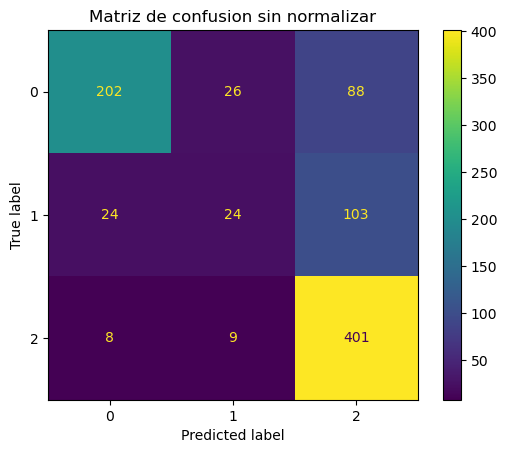

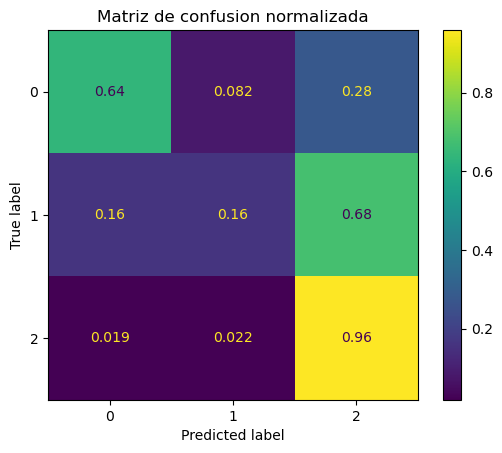

In [22]:
# MATRIZ DE CONFUSION KNN (SIN NORMALIZAR Y NORMALIZADA)
from sklearn.metrics import ConfusionMatrixDisplay

titles_options = [
    ("Matriz de confusion sin normalizar", None),
    ("Matriz de confusion normalizada", "true")
]

for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred_knn_final,
        normalize=normalize
    )
    disp.ax_.set_title(title)
    print(title)
    print(disp.confusion_matrix)
plt.show()


Matriz de confusion sin normalizar
[[216  34  66]
 [ 28  38  85]
 [ 24  35 359]]
Matriz de confusion normalizada
[[0.6835443  0.10759494 0.20886076]
 [0.18543046 0.25165563 0.56291391]
 [0.05741627 0.08373206 0.85885167]]


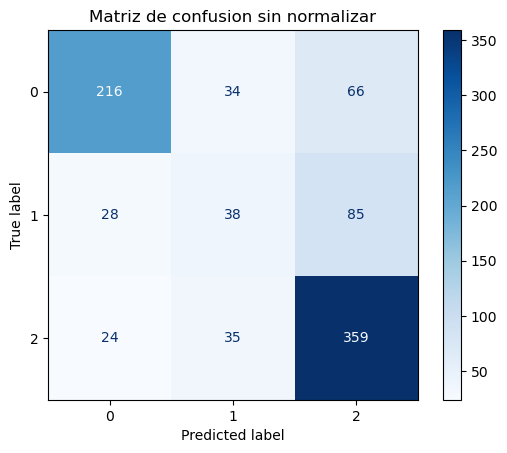

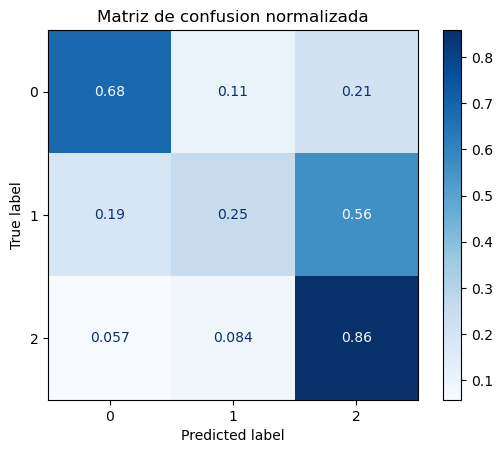

In [23]:
# MATRIZ DE CONFUSION NAIVE BAYES (SIN NORMALIZAR Y NORMALIZADA)
titles_options = [
    ("Matriz de confusion sin normalizar", None),
    ("Matriz de confusion normalizada", "true")
]

for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred_nb,
        cmap=plt.cm.Blues,
        normalize=normalize
    )
    disp.ax_.set_title(title)
    print(title)
    print(disp.confusion_matrix)
plt.show()


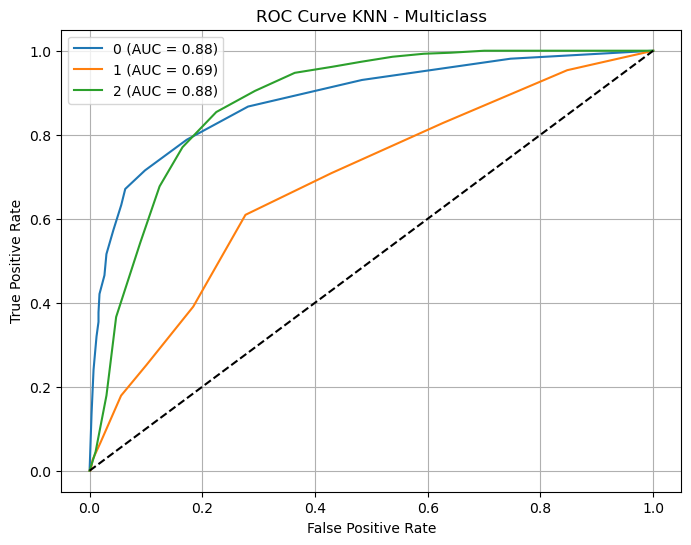

In [24]:
# CURVA ROC MULTICLASE - KNN
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

clases = knn_final.classes_
y_test_bin = label_binarize(y_test, classes=clases)

y_pred_prob_knn = knn_final.predict_proba(X_test)

plt.figure(figsize=(8, 6))

for i, clase in enumerate(clases):
    fpr, tpr, thresholds = roc_curve(
        y_test_bin[:, i],
        y_pred_prob_knn[:, i]
    )
    roc_auc_i = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{clase} (AUC = {roc_auc_i:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve KNN - Multiclass')
plt.legend()
plt.grid()
plt.show()


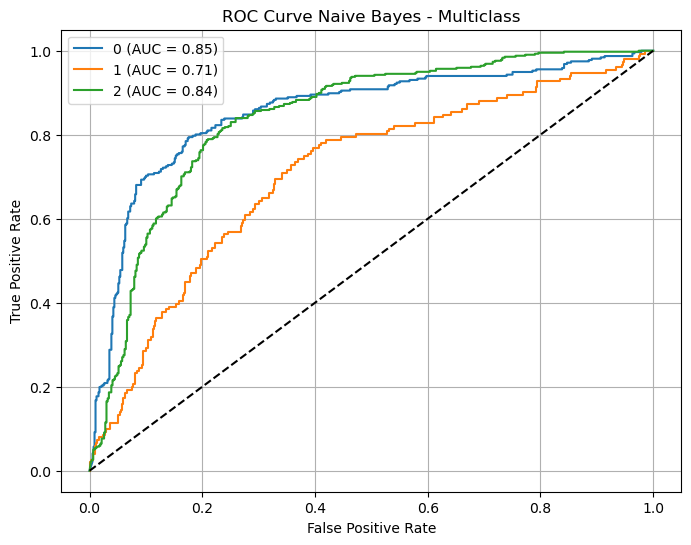

In [25]:
# CURVA ROC MULTICLASE - NAIVE BAYES
y_pred_prob_nb = nb.predict_proba(X_test)

plt.figure(figsize=(8, 6))

for i, clase in enumerate(clases):
    fpr, tpr, thresholds = roc_curve(
        y_test_bin[:, i],
        y_pred_prob_nb[:, i]
    )
    roc_auc_i = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{clase} (AUC = {roc_auc_i:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Naive Bayes - Multiclass')
plt.legend()
plt.grid()
plt.show()


In [26]:
# TABLA RESUMEN CON RESULTADOS DE TEST, PREDICCION Y PROBABILIDADES (KNN)
dataf = pd.concat([
    pd.DataFrame(X_test),
    pd.DataFrame(y_test.values, columns=['y_test']),
    pd.DataFrame(y_pred_knn_final, columns=['y_pred']),
    pd.DataFrame(y_pred_prob_knn)
], axis=1)

dataf.head()


,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,y_test,y_pred,0,1,2
0,4.658294,1.162916,-0.554068,0.132483,0.350082,-0.35023,0.036907,-0.126298,-1.061566,-1.386793,...,-0.044184,-0.199441,-0.175007,-0.454253,0.889126,0,0,0.5000,0.1250,0.3750
1,-0.294829,-0.095470,-0.554068,0.184826,0.350082,-0.35023,-0.577342,-0.126298,-0.997469,-1.256427,...,0.367096,-0.199441,1.739731,-0.671242,-0.406211,2,2,0.0625,0.2500,0.6875
2,-0.294829,-0.095470,-0.554068,0.482887,0.350082,-0.35023,0.029324,-0.126298,1.181819,1.024985,...,0.394515,-0.199441,1.739731,-0.671242,-0.406211,2,2,0.0000,0.0000,1.0000
3,-0.294829,-0.095470,0.207173,0.394196,0.350082,-0.35023,-1.714839,-0.126298,-1.189759,-1.386793,...,0.531608,-0.199441,1.476924,1.137005,-1.789667,2,2,0.2500,0.1875,0.5625
4,-0.294829,1.162916,-0.554068,0.311805,0.350082,-0.35023,-0.198176,-0.126298,1.117723,-0.213496,...,-1.963489,-0.199441,-0.175007,-0.454253,0.889126,0,0,0.9375,0.0625,0.0000


In [27]:
# CONCLUSION AUTOMATICA SEGUN ROC-AUC
if roc_knn > roc_nb:
    mejor_modelo = "KNN"
else:
    mejor_modelo = "Naive Bayes"

print(f"ROC-AUC KNN: {roc_knn:.2f}")
print(f"ROC-AUC Naive Bayes: {roc_nb:.2f}")
print(f"El modelo con mejor desempeño segun ROC-AUC es: {mejor_modelo}")


ROC-AUC KNN: 0.79
ROC-AUC Naive Bayes: 0.80
El modelo con mejor desempeño segun ROC-AUC es: Naive Bayes


## Conclusiones

- Se probaron dos modelos de clasificacion: KNN y Naive Bayes, para predecir la variable Target.
- Se aplico StandardScaler para escalar las variables, ya que KNN se basa en distancias y es sensible a la escala de los datos.
- Se probaron varios valores de k (de 1 a 30) usando validacion cruzada (cv=5) y se grafico k vs accuracy para elegir el mejor valor, en lugar de fijarlo de forma arbitraria.
- Se generaron las matrices de confusion normalizadas y sin normalizar para ambos modelos, lo que permite ver en que clases se equivoca mas cada uno.
- Se graficaron las curvas ROC multiclase (una curva por clase) para KNN y Naive Bayes.
- Segun la metrica ROC-AUC (ver celda anterior), el modelo con mejor desempeño fue el impreso arriba.
